In [1]:
%matplotlib inline

In [2]:
import xtrack as xt
import xpart as xp
import matplotlib.pyplot as plt

import numpy as np

### Compute multi-species ratios

In [3]:
# Create particles
p0_car = xt.Particles('Carbon-12')
p0_hel = xt.Particles('Helium-4')

In [5]:
# Compute He/C ratios
mass_ratio_hel_car = p0_hel.mass0 / p0_car.mass0
charge_ratio_hel_car = p0_hel.q0 / p0_car.q0
chi_hel = charge_ratio_hel_car / mass_ratio_hel_car

### Load the line

In [6]:
env = xt.load('./pimm.json')
env.vars.load('./pimm_strengths.json')
line = env.ring
# Use a slightly simplified model for tracking speed:
line.configure_bend_model(num_multipole_kicks=5)

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

In [7]:
env.new('extr_septum', xt.Marker)
env.new('septum_aperture', xt.LimitRect, min_x=-0.1, max_x=0.1, min_y=-0.1, max_y=0.1)

line.insert(['extr_septum', 'septum_aperture'], at=0)

Slicing line:   0%|          | 0/109 [00:00<?, ?it/s]

### Set Carbon at 200 MeV / nucleon as reference particle

In [8]:
line.set_particle_ref('Carbon-12', kinetic_energy0=200e6 * 12)

### Configure machine for slow extraction

In [9]:
# Qx close to resonance
env['tune_x'] = 1.665

# Extraction sextupole ON
env['kse'] = 3.

# Zero chromaticity
env['chrom_x'] = 0
env['chrom_y'] = 0

In [10]:
tw = line.twiss4d()
print(f"Qx={tw.qx:.4f}, Q'x={tw.dqx:.3f}, Q'y={tw.dqy:.3f}")

Qx=1.6650, Q'x=-0.002, Q'y=-0.005


### Compute expected momentum difference

In [11]:
alpha = tw.momentum_compaction_factor
eta = tw.slip_factor
delta_diff_expected = alpha / eta * (chi_hel - 1)

### Inspect horizontal phase space for C and He ($Q'_x$ = 0)

In [12]:
# Generate probe particles with different horizontal positions
x_gen = np.linspace(1e-5, 1e-2, 20)

p0_car = line.build_particles(x=x_gen, px=0, y=0, py=0, zeta=0, delta=0)
p0_hel = line.build_particles(x=x_gen, px=0, y=0, py=0, zeta=0, delta=delta_diff_expected,
                              mass_ratio=mass_ratio_hel_car, charge_ratio=charge_ratio_hel_car)

In [13]:
# Track the two particle sets logging turn-by-turn data
p_car = p0_car.copy()
line.track(p_car, num_turns=1000, turn_by_turn_monitor=True,
           with_progress=True)
rec_car = line.record_last_track

p_hel = p0_hel.copy()
line.track(p_hel, num_turns=1000, turn_by_turn_monitor=True,
           with_progress=True)
rec_hel = line.record_last_track

Tracking:   0%|          | 0/1000 [00:00<?, ?it/s]

Tracking:   0%|          | 0/1000 [00:00<?, ?it/s]

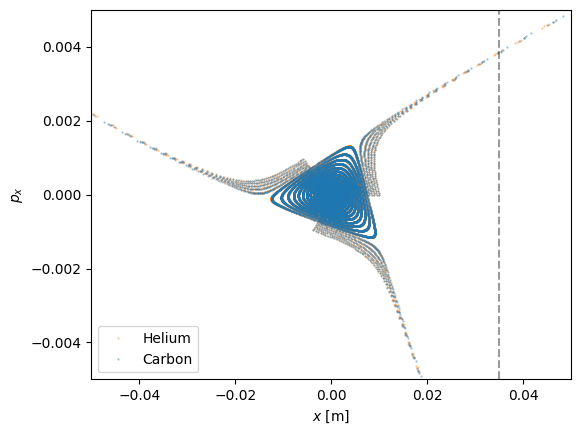

In [15]:
x_septum = 3.5e-2

# Plot turn-by-turn data
plt.figure()
plt.plot(rec_hel.x.flatten(), rec_hel.px.flatten(), '.', markersize=1, color='C1', alpha=0.5, label='Helium')
plt.plot(rec_car.x.flatten(), rec_car.px.flatten(), '.', markersize=1, color='C0', alpha=0.5, label='Carbon')
plt.xlabel(r'$x$ [m]'); plt.ylabel(r'$p_x$'), plt.xlim(-5e-2, 5e-2); plt.ylim(-5e-3, 5e-3)
plt.axvline(x=x_septum, color='k', alpha=0.4, linestyle='--')
plt.subplots_adjust(left=.15)
plt.legend()

### Inspect horizontal phase space for C and He ($Q'_x$ = 1)
We do the same comparison for non-linear chromaticity

In [16]:
env['chrom_x'] = 1.

In [17]:
# Track the two particle sets logging turn-by-turn data
p_car = p0_car.copy()
line.track(p_car, num_turns=1000, turn_by_turn_monitor=True,
           with_progress=True)
rec_car = line.record_last_track

p_hel = p0_hel.copy()
line.track(p_hel, num_turns=1000, turn_by_turn_monitor=True,
           with_progress=True)
rec_hel = line.record_last_track

Tracking:   0%|          | 0/1000 [00:00<?, ?it/s]

Tracking:   0%|          | 0/1000 [00:00<?, ?it/s]

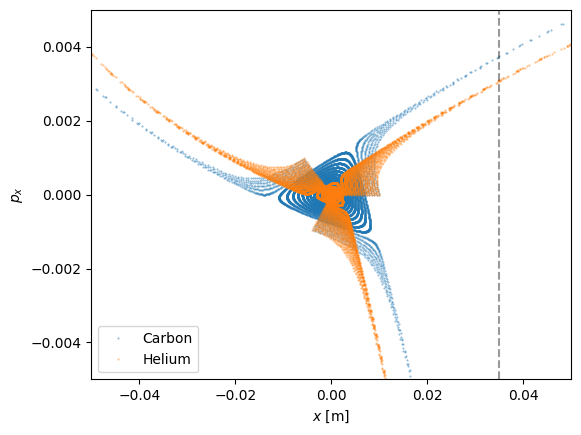

In [19]:
# Plot turn-by-turn data
plt.figure()
plt.plot(rec_car.x.flatten(), rec_car.px.flatten(), '.', markersize=1, color='C0', alpha=0.5, label='Carbon')
plt.plot(rec_hel.x.flatten(), rec_hel.px.flatten(), '.', markersize=1, color='C1', alpha=0.5, label='Helium')
plt.xlabel(r'$x$ [m]'); plt.ylabel(r'$p_x$'), plt.xlim(-5e-2, 5e-2); plt.ylim(-5e-3, 5e-3)
plt.axvline(x=x_septum, color='k', alpha=0.4, linestyle='--')
plt.subplots_adjust(left=.15)
plt.legend()

### Frequency analysis on particle motion

We use Xsuite's sister package `nafflib`. It can be installed simply with `pip install nafflib`

In [20]:
import nafflib

In [21]:
qx_hel = []
qx_car = []
for ii in range(len(x_gen)):
    qx_hel.append(nafflib.get_tune(rec_hel.x[ii, :] + 1j * rec_hel.px[ii, :]))
    qx_car.append(nafflib.get_tune(rec_car.x[ii, :] + 1j * rec_car.px[ii, :]))
qx_hel = np.asarray(qx_hel)
qx_car = np.asarray(qx_car)

Text(0, 0.5, 'Qx')

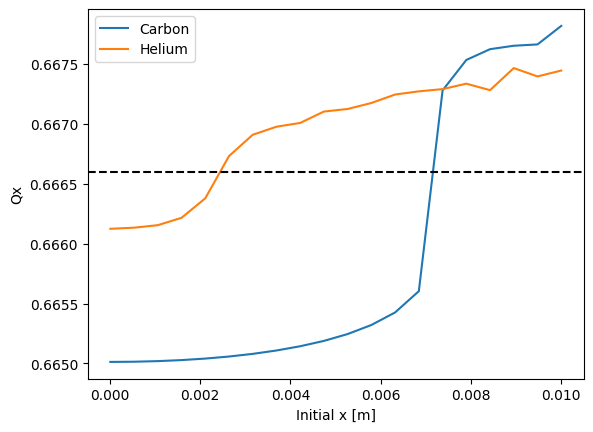

In [22]:
plt.plot(x_gen, 1. - qx_car, label='Carbon')
plt.plot(x_gen, 1. - qx_hel, label='Helium')
plt.axhline(y=0.6666, linestyle='--', color='k')
plt.legend()
plt.xlabel('Initial x [m]')
plt.ylabel('Qx')